<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/Day7_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/polynomial_regression_dataset.csv")

In [ ]:
df.head()

,Temperature,Pressure
0,10.000000,6.993428
1,14.736842,4.526795
2,19.473684,5.350779
3,24.210526,6.802292
4,28.947368,3.437510


In [ ]:
x=df[["Temperature"]]
y=df[["Pressure"]]

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin=LinearRegression()
lin.fit(x,y)

LinearRegression()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=4)
x_poly=poly.fit_transform(x)

poly.fit(x_poly,y)
lin2=LinearRegression()
lin2.fit(x_poly,y)

LinearRegression()

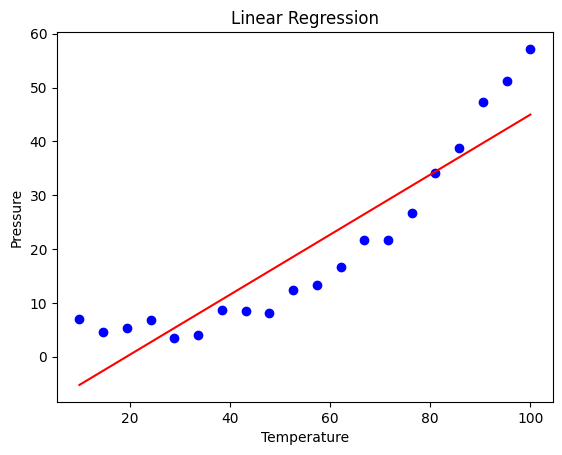

In [ ]:
plt.scatter(x,y,color="blue")

plt.plot(x,lin.predict(x),color="red")
plt.title("Linear Regression")
plt.xlabel("Temperature")
plt.ylabel("Pressure")

plt.show()



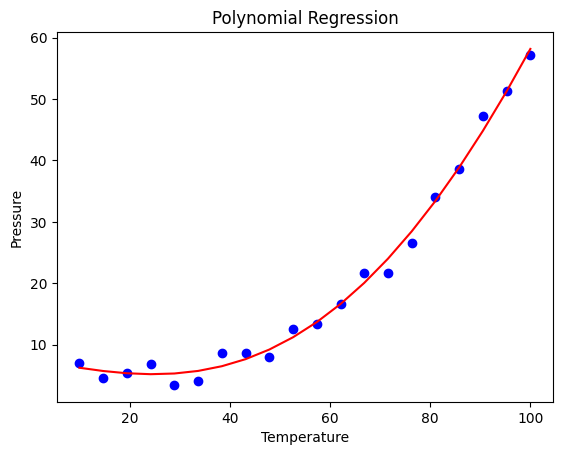

In [ ]:
plt.scatter(x,y,color="blue")

plt.plot(x,lin2.predict(poly.fit_transform(x)),color="red")
plt.title("Polynomial Regression")
plt.xlabel("Temperature")
plt.ylabel("Pressure")

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("sustainability_data.csv")

In [ ]:
x=data[["Energy_Consumption","Renewable_Percentage","GDP"]]
y=data[["CO2_Emissions"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
poly = PolynomialFeatures(degree=2)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_poly_train, y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_poly_test)

In [ ]:
y_pred

array([[ 734.07298491],
       [ 874.62164867],
       [ 947.22015401],
       [ 858.08950479],
       [1027.78382866]])

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("Mean Squared Error:",{mse})
print("R-squared:",{r2})

Mean Squared Error: {2341.1134159353965}
R-squared: {0.06978468406875404}


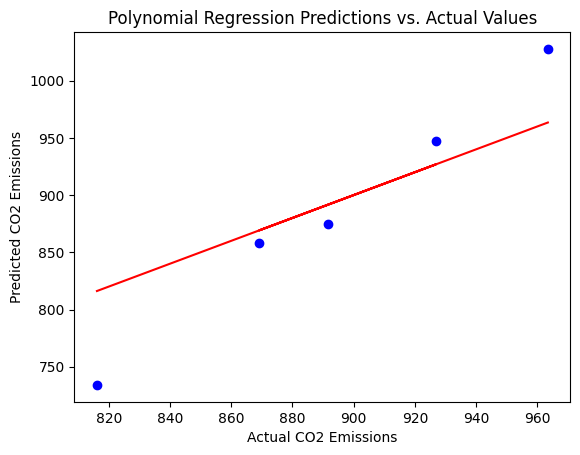

In [ ]:
plt.scatter(y_test,y_pred,color="blue")
plt.plot(y_test,y_test,color="red")
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Polynomial Regression Predictions vs. Actual Values")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/green_tech_data.csv")
data.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


In [ ]:
data.shape

(100, 5)

In [ ]:
data.isnull().sum()

,0
carbon_emissions,0
energy_output,0
renewability_index,0
cost_efficiency,0
sustainability,0


In [ ]:
x=data[["carbon_emissions","energy_output","renewability_index","cost_efficiency"]]
y=data["sustainability"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [ ]:
data.head(7)

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0
5,104.598082,324.363006,0.009197,4.891334,0
6,70.329264,469.344631,0.101472,2.823352,0


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.95


In [ ]:
conf_matrix=confusion_matrix(y_test,y_pred)
print(conf_matrix)

[[17  0]
 [ 1  2]]


In [ ]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Not Sustainable', 'Sustainable']))

                 precision    recall  f1-score   support

Not Sustainable       0.94      1.00      0.97        17
    Sustainable       1.00      0.67      0.80         3

       accuracy                           0.95        20
      macro avg       0.97      0.83      0.89        20
   weighted avg       0.95      0.95      0.95        20



In [ ]:
import joblib
# Save the model to a file
joblib.dump(model, 'lrmodel_sustainable.pkl')

['lrmodel_sustainable.pkl']